In [1]:
# WMT cold pool with shanice!

In [69]:
import xarray as xr
import json
#import gcsfs
import numpy as np
#import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
import matplotlib.pyplot as plt
import dask
import dask.array as dsa
from xgcm import Grid
import xgcm 
from xgcm.autogenerate import generate_grid_ds
from xhistogram.xarray import histogram
from shapely.geometry import Polygon, Point, MultiPolygon

In [11]:
#!pip install xhistogram

In [2]:
# Open the glorys data.  It was too large to download all at once so is split into 2 datasets which will be merged together
glorys1 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/global-reanalysis-phy-001-030-monthly_1630441480776.nc')

In [3]:
glorys2 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/global-reanalysis-phy-001-030-monthly_1630526463376.nc')

In [4]:
# 2022 update - 2020 data now available
glorys3 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/cmems_mod_glo_phy_my_0.083_P1M-m_1671121556932.nc')

In [6]:
glorys = xr.merge([glorys1,glorys2,glorys3])

In [19]:
glorys.longitude

<xarray.DataArray 'longitude' (longitude: 241)>
array([-80.      , -79.916664, -79.833336, ..., -60.166668, -60.083332,
       -60.      ], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Attributes:
    valid_min:            -80.0
    valid_max:            -60.0
    step:                 0.08332825
    units:                degrees_east
    unit_long:            Degrees East
    long_name:            Longitude
    standard_name:        longitude
    axis:                 X
    _ChunkSizes:          4320
    _CoordinateAxisType:  Lon

In [116]:
# Load EPU shapefile
LME = gpd.read_file('/Users/nyelab/Downloads/LME66/LMEs66.shp')
# Load NYB shapefile
NYB = gpd.read_file('/Users/nyelab/Desktop/NYB Indicators/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')
# Alter the projection to WGS84 see https://epsg.io/4326
NYB = NYB.to_crs(epsg=4326)

nyb_shape = NYB.geometry[0]

NYB_no = gpd.read_file('/Users/nyelab/Desktop/NYB Indicators/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp', ignore_geometry=True)

In [123]:
nyb_shape?

Type:           Polygon
String form:    POLYGON ((-71.66878928485043 41.05893259677281, -71.64509029797523 40.94925361689265, -71.5651343 <...> 5 41.07483959721262, -71.69165627625996 41.07549859397375, -71.66878928485043 41.05893259677281))
File:           ~/miniconda3/lib/python3.8/site-packages/shapely/geometry/polygon.py
Docstring:     
A two-dimensional figure bounded by a linear ring

A polygon has a non-zero area. It may have one or more negative-space
"holes" which are also bounded by linear rings. If any rings cross each
other, the feature is invalid and operations on it may fail.

Attributes
----------
exterior : LinearRing
    The ring which bounds the positive space of the polygon.
interiors : sequence
    A sequence of rings which bound all existing holes.
Init docstring:
Parameters
----------
shell : sequence
    A sequence of (x, y [,z]) numeric coordinate pairs or triples.
    Also can be a sequence of Point objects.
holes : sequence
    A sequence of objects which sati

In [133]:
df =gpd.GeoDataFrame(nyb_shape[0], geometry='geometry', crs = 4326)

TypeError: 'Polygon' object is not subscriptable

AttributeError: 'GeoDataFrame' object has no attribute 'cols'

In [73]:
# Function that checks if the points are within the NYB (variable with depth - FOR COLD POOL)
def inNYB(longitude, latitude, time, depth, var, shape):
    X = longitude
    Y = latitude
    x, y = np.meshgrid(X, Y)
    empty = np.empty([len(time), len(depth), len(latitude), len(longitude)])
    empty[:,:,:,:] = np.nan
    for i in range(len(latitude)):
        for j in range(len(longitude)):
            if Point(x[i,j], y[i,j]).within(shape) == True:
                empty[:,:,i,j] = var[:,:,i,j]
    return empty

In [75]:
temp_in_nyb = inNYB(glorys.longitude,glorys.latitude,glorys.time,glorys.depth, glorys.thetao, nyb_shape)

In [84]:
glorys_temp = xr.Dataset(data_vars = {'thetao': (['time','depth','latitude','longitude'],temp_in_nyb)},
                        coords = {'time': glorys.time,
                                 'depth': glorys.depth,
                                 'latitude': glorys.latitude,
                                 'longitude': glorys.longitude})

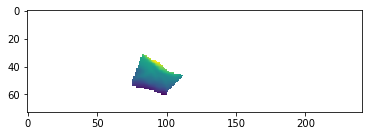

In [80]:
np.shape(temp_in_nyb)
plt.imshow(temp_in_nyb[0,5,:,:])

In [114]:
NYB.geometry

In [86]:
#ds_pt = generate_grid_ds(pot_temp, {'X': 'x', 'Y':'y'})
ds_pt_full = generate_grid_ds(glorys_temp, {'X': 'longitude', 'Y':'latitude'})

In [87]:
grid_pt_full = xgcm.Grid(ds_pt_full, periodic=['X', 'Y'], boundary="fill", fill_value=0.)
#grid_pt = xgcm.Grid(ds_pt, periodic=['X'])

In [ ]:
#grid = xgcm.Grid(ds_full, periodic=['X'])

In [88]:
def deg_2_m(grid_obj, ds_obj, lat, lon):
   
    #calculating meters per latitudinal & longitudinal degree
    earth_radius = 6.371e6
    earth_circumference = 2*np.pi*earth_radius
    meters_per_degree = earth_circumference / 360
    meters_per_degree
    
    #converting lat from degrees to meters
    delta_lat = grid_obj.diff(ds_obj[f'{lat}'].astype('f4'), 'Y', boundary='fill', fill_value=np.nan)
    dy = delta_lat * meters_per_degree
    delta_lat_l = grid_obj.diff(ds_obj[f'{lat}_left'].astype('f4'), 'Y', boundary='fill', fill_value=np.nan)
    dy_l = delta_lat_l * meters_per_degree

    #converting degrees lon to lon [meters] (pinching at the poles)
    delta_lon = grid_obj.diff(ds_obj[f'{lon}'].astype('f4'), 'X')#, boundary_discontinuity=360)
    dx = delta_lon * meters_per_degree * np.cos(np.deg2rad(ds_obj[f'{lat}'].astype('f4')))
    delta_lon_l = grid_obj.diff(ds_obj[f'{lon}_left'].astype('f4'), 'X')#, boundary_discontinuity=360)
    dx_l = delta_lon_l * meters_per_degree * np.cos(np.deg2rad(ds_obj[f'{lat}_left'].astype('f4')))
    
    elements = xr.merge([dx.rename('dx'), dx_l.rename('dx_l'), 
                          dy.rename('dy'), dy_l.rename('dy_l')])
    
    return (elements)


In [89]:
cell_elements = deg_2_m(grid_pt_full, ds_pt_full, 'latitude', 'longitude')

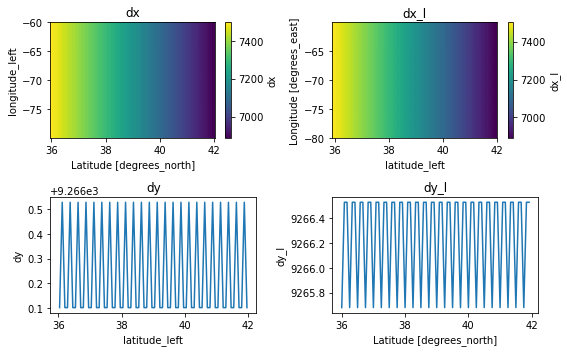

In [90]:
fig, ax = plt.subplots(2,2, figsize=(8,5))
cell_elements.dx[1:].plot(ax=ax[0,0])
ax[0,0].set_title('dx')
cell_elements.dx_l[:-1].plot(ax=ax[0,1])
ax[0,1].set_title('dx_l')
cell_elements.dy[1:].plot(ax=ax[1,0])
ax[1,0].set_title('dy')
cell_elements.dy_l[:-1].plot(ax=ax[1,1])
ax[1,1].set_title('dy_l')
plt.tight_layout();


In [33]:
cell_elements.dx_l

<xarray.DataArray 'dx_l' (longitude: 241, latitude_left: 73)>
array([[    7501.423 ,     7493.5005,     7485.562 , ...,     6909.5044,
            6900.514 ,     6891.5093],
       [    7500.05  ,     7492.129 ,     7484.192 , ...,     6908.2397,
            6899.251 ,     6890.2476],
       [    7500.05  ,     7492.129 ,     7484.192 , ...,     6908.2397,
            6899.251 ,     6890.2476],
       ...,
       [    7500.737 ,     7492.8154,     7484.877 , ...,     6908.8726,
            6899.883 ,     6890.879 ],
       [    7500.737 ,     7492.8154,     7484.877 , ...,     6908.8726,
            6899.883 ,     6890.879 ],
       [-1800122.5   , -1798221.4   , -1796316.4   , ..., -1658079.4   ,
        -1655921.9   , -1653761.    ]], dtype=float32)
Coordinates:
  * longitude      (longitude) float32 -80.0 -79.92 -79.83 ... -60.08 -60.0
  * latitude_left  (latitude_left) float32 35.96 36.04 36.12 ... 41.88 41.96

In [91]:
dx_interp = grid_pt_full.interp(cell_elements.dx_l,'Y')

In [92]:
dz = glorys.depth.diff(dim='depth',label='upper')

In [93]:
dx_interp[:,:-1].coords


Coordinates:
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.75 41.83 41.92

In [94]:
cell_elements.dy_l[:-1].coords

Coordinates:
  * latitude  (latitude) float32 36.0 36.08 36.17 36.25 ... 41.75 41.83 41.92

In [95]:
vol = cell_elements.dy_l[:-1]*dx_interp[:,:-1]*dz
vol.coords

Coordinates:
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.75 41.83 41.92
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
  * depth      (depth) float32 1.541 2.646 3.819 ... 1.942e+03 2.225e+03

In [96]:
glorys.coords

Coordinates:
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2020-12-16T12:00:00
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0

In [97]:
glorys.thetao

<xarray.DataArray 'thetao' (time: 336, depth: 41, latitude: 73, longitude: 241)>
array([[[[       nan,        nan,        nan, ..., 19.525589 ,
          19.58858  , 19.643513 ],
         [       nan,        nan,        nan, ..., 19.283884 ,
          19.36372  , 19.449415 ],
         [       nan,        nan,        nan, ..., 19.098576 ,
          19.178411 , 19.284616 ],
         ...,
         [       nan,        nan,        nan, ..., 12.208472 ,
          12.187231 , 12.250954 ],
         [       nan,        nan,        nan, ..., 12.006317 ,
          11.995331 , 12.110325 ],
         [       nan,        nan,        nan, ..., 11.68038  ,
          11.725791 , 11.936003 ]],

        [[       nan,        nan,        nan, ..., 19.525589 ,
          19.58858  , 19.643513 ],
         [       nan,        nan,        nan, ..., 19.283884 ,
          19.36372  , 19.449415 ],
         [       nan,        nan,        nan, ..., 19.098576 ,
          19.178411 , 19.284616 ],
...
         [       nan,        nan,        nan, ...,  3.5282745,
           3.52388  ,  3.52388  ],
         [       nan,        nan,        nan, ...,  3.5319386,
           3.5334034,  3.5385303],
         [       nan,        nan,        nan, ...,  3.5304718,
           3.5385303,  3.5480518]],

        [[       nan,        nan,        nan, ...,  3.4154797,
           3.3869133,  3.3693352],
         [       nan,        nan,        nan, ...,  3.4154797,
           3.3883781,  3.3744621],
         [       nan,        nan,        nan, ...,  3.4132824,
           3.3891106,  3.3788567],
         ...,
         [       nan,        nan,        nan, ...,  3.162054 ,
           3.1525307,  3.1459389],
         [       nan,        nan,        nan, ...,  3.1481361,
           3.1430092,  3.139347 ],
         [       nan,        nan,        nan, ...,  3.1298256,
           3.130558 ,  3.1320229]]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2020-12-16T12:00:00
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Attributes:
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    cell_methods:   area: mean
    _ChunkSizes:    [  1   7 341 720]

In [102]:
masked_vol = vol.where(glorys_temp.thetao[:,1:,:-1,:]<=10) #m^3

In [103]:
vol_tot = masked_vol.sum(['latitude','longitude','depth'])#m^3

In [104]:
M = vol_tot*1034 #kg
V = M/1034 #m^3



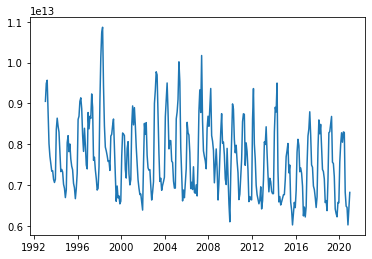

In [105]:
plt.plot(glorys.time, V)

In [106]:
dVdt = V.diff('time', label='upper') / (60*60*24*30.437) #m^3s

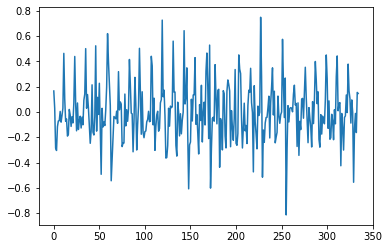

In [109]:
plt.plot(dVdt/1e6)

In [111]:
(4e12/(30*24*60*60))/1e6

1.5432098765432098

In [135]:
!pip install copernicusmarin

ERROR: Could not find a version that satisfies the requirement copernicusmarine (from versions: none)
ERROR: No matching distribution found for copernicusmarine


In [140]:
test = xr.open_dataset('/Users/nyelab/Downloads/cmems_mod_glo_phy_my_0.083deg_P1D-m_1706290181212.nc')

In [141]:
test

<xarray.Dataset>
Dimensions:    (depth: 25, latitude: 109, longitude: 180, time: 152)
Coordinates:
  * depth      (depth) float32 1.541 2.646 3.819 5.078 ... 130.7 155.9 186.1
  * latitude   (latitude) float32 34.0 34.08 34.17 34.25 ... 42.83 42.92 43.0
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -65.25 -65.17 -65.08
  * time       (time) datetime64[ns] 1993-01-01 1993-01-02 ... 1993-06-01
Data variables:
    bottomT    (time, latitude, longitude) float32 ...
    mlotst     (time, latitude, longitude) float32 ...
    so         (time, depth, latitude, longitude) float32 ...
    thetao     (time, depth, latitude, longitude) float32 ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       MERCATOR OCEAN
    source:            MERCATOR GLORYS12V1
    history:           2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    references:        http://www.mercator-ocean.fr
    comment:           CMEMS product
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1D-m_202311
    subset:date:       2024-01-26T17:29:41.213Z